In [ ]:
#Hyperparameter Tuning & Neural Networks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load  models and data 
import joblib
try:
    X_train_scaled = joblib.load('X_train_scaled.pkl')
    X_test_scaled = joblib.load('X_test_scaled.pkl')
    X_train = joblib.load('X_train.pkl')
    X_test = joblib.load('X_test.pkl')
    y_train = joblib.load('y_train.pkl')
    y_test = joblib.load('y_test.pkl')
    print("Loaded data from yesterday!")
except:
    print("Loading fresh data...")
    # Load your prepared data
    data = joblib.load('prepared_data.pkl')
    X = data['X']
    y = data['y']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Save for later
    joblib.dump(X_train_scaled, 'X_train_scaled.pkl')
    joblib.dump(X_test_scaled, 'X_test_scaled.pkl')
    joblib.dump(X_train, 'X_train.pkl')
    joblib.dump(X_test, 'X_test.pkl')
    joblib.dump(y_train, 'y_train.pkl')
    joblib.dump(y_test, 'y_test.pkl')
    joblib.dump(scaler, 'scaler.pkl')

print(f"\nTraining data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

Loaded data from yesterday!

Training data: (5634, 16)
Testing data: (1409, 16)


In [ ]:
print("HYPERPARAMETER TUNING - RANDOM FOREST")

# Define parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, 15, None],   # How deep trees can grow
    'min_samples_split': [2, 5, 10],   # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],      # Minimum samples in leaf nodes
    'max_features': ['sqrt', 'log2']    # Features to consider for best split
}

print("\nSearching for best parameters...")
print(f"Testing{len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['max_features'])} combinations")

# Create GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
print("\n Training (this may take 2-3 minutes)...")
rf_grid.fit(X_train, y_train)

print("\nBest Parameters Found:")
for param, value in rf_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nBest CV Score: {rf_grid.best_score_:.4f}")

# Evaluate on test set
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print(f"\n Tuned Random Forest Performance:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf_tuned):.4f}")

HYPERPARAMETER TUNING - RANDOM FOREST

Searching for best parameters...
Testing216 combinations

⏳ Training (this may take 2-3 minutes)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters Found:
   max_depth: 5
   max_features: sqrt
   min_samples_leaf: 4
   min_samples_split: 10
   n_estimators: 100

Best CV Score: 0.8407

📊 Tuned Random Forest Performance:
   Accuracy:  0.7956
   Precision: 0.6617
   Recall:    0.4706
   F1-Score:  0.5500
   ROC-AUC:   0.8408


In [ ]:
print(" HANDLING CLASS IMBALANCE WITH SMOTE")

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("\n Applying SMOTE to balance classes...")
print(f"   Before SMOTE - Class distribution:")
print(f"   Class 0: {sum(y_train==0)} samples")
print(f"   Class 1: {sum(y_train==1)} samples")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n   After SMOTE - Class distribution:")
print(f"   Class 0: {sum(y_train_smote==0)} samples")
print(f"   Class 1: {sum(y_train_smote==1)} samples")

# Train Random Forest on balanced data
rf_balanced = RandomForestClassifier(**rf_grid.best_params_, random_state=42)
rf_balanced.fit(X_train_smote, y_train_smote)

# Evaluate
y_pred_balanced = rf_balanced.predict(X_test)
y_pred_proba_balanced = rf_balanced.predict_proba(X_test)[:, 1]

print(f"\n Balanced Random Forest Performance:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred_balanced):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_balanced):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_balanced):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_balanced):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_balanced):.4f}")

 HANDLING CLASS IMBALANCE WITH SMOTE

🔧 Applying SMOTE to balance classes...
   Before SMOTE - Class distribution:
   Class 0: 4139 samples
   Class 1: 1495 samples

   After SMOTE - Class distribution:
   Class 0: 4139 samples
   Class 1: 4139 samples

📊 Balanced Random Forest Performance:
   Accuracy:  0.7431
   Precision: 0.5107
   Recall:    0.7674
   F1-Score:  0.6132
   ROC-AUC:   0.8277


In [ ]:
print("\n" + "=" * 60)
print("STEP 3: BUILDING A NEURAL NETWORK")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(" TensorFlow imported!")

# Build the neural network
def create_neural_network(input_dim):
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),
        
        # First hidden layer
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Second hidden layer
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        # Third hidden layer
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        
        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    
    return model

# Create model
nn_model = create_neural_network(X_train_scaled.shape[1])
print("\n Neural Network Architecture:")
nn_model.summary()

# Callbacks for training
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

# Train the neural network
print("\n Training Neural Network (this may take 2-3 minutes)...")
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=0
)

print(" Neural Network trained!")

# Evaluate
y_pred_proba_nn = nn_model.predict(X_test_scaled, verbose=0)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

print(f"\n Neural Network Performance:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_nn):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_nn):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_nn):.4f}")


STEP 3: BUILDING A NEURAL NETWORK
✅ TensorFlow imported!

📐 Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 12,993 (50.75 KB)

 Non-trainable params: 448 (1.75 KB)


⏳ Training Neural Network (this may take 2-3 minutes)...
✅ Neural Network trained!

📊 Neural Network Performance:
   Accuracy:  0.7899
   Precision: 0.6242
   Recall:    0.5241
   F1-Score:  0.5698
   ROC-AUC:   0.8332



STEP 4: NEURAL NETWORK TRAINING HISTORY


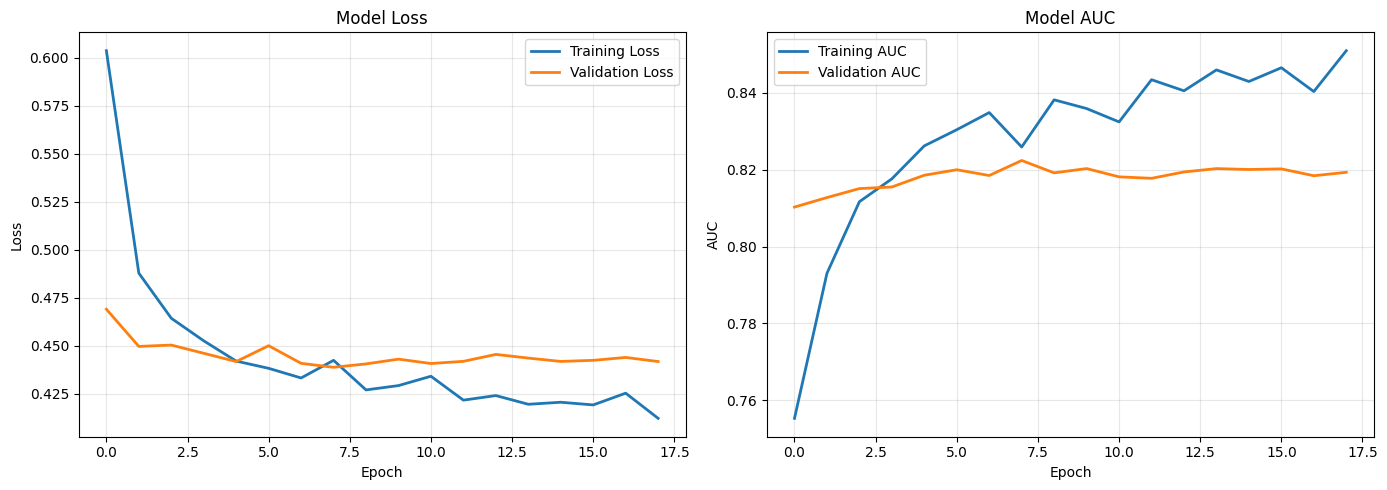

✅ Training curves saved!


In [ ]:
print("NEURAL NETWORK TRAINING HISTORY")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training & validation loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot training & validation AUC
axes[1].plot(history.history['auc'], label='Training AUC', linewidth=2)
axes[1].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Model AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('neural_network_training.png', dpi=100, bbox_inches='tight')
plt.show()

print("Training curves saved!")

In [ ]:
print("COMPARING ALL MODELS")


# Load original models from yesterday
try:
    lr_model = joblib.load('logistic_regression_model.pkl')
    rf_model = joblib.load('random_forest_model.pkl')
    y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
except:
    print("  Couldn't load yesterday's models")

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Tuned Random Forest', 
              'Balanced RF', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, (y_pred_proba_lr > 0.5).astype(int)),
        accuracy_score(y_test, (y_pred_proba_rf > 0.5).astype(int)),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_nn)
    ],
    'Precision': [
        precision_score(y_test, (y_pred_proba_lr > 0.5).astype(int)),
        precision_score(y_test, (y_pred_proba_rf > 0.5).astype(int)),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_nn)
    ],
    'Recall': [
        recall_score(y_test, (y_pred_proba_lr > 0.5).astype(int)),
        recall_score(y_test, (y_pred_proba_rf > 0.5).astype(int)),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_nn)
    ],
    'F1-Score': [
        f1_score(y_test, (y_pred_proba_lr > 0.5).astype(int)),
        f1_score(y_test, (y_pred_proba_rf > 0.5).astype(int)),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_nn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_rf_tuned),
        roc_auc_score(y_test, y_pred_proba_balanced),
        roc_auc_score(y_test, y_pred_proba_nn)
    ]
})

print("\n ALL MODELS COMPARISON:")
print(comparison.round(4).to_string(index=False))

# Find best model
best_model_idx = comparison['ROC-AUC'].argmax()
print(f"\n BEST MODEL: {comparison.iloc[best_model_idx]['Model']}")
print(f"   with ROC-AUC: {comparison.iloc[best_model_idx]['ROC-AUC']:.4f}")


STEP 5: COMPARING ALL MODELS

📊 ALL MODELS COMPARISON:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7999     0.6523  0.5267    0.5828   0.8422
      Random Forest    0.8027     0.6548  0.5428    0.5936   0.8420
Tuned Random Forest    0.7956     0.6617  0.4706    0.5500   0.8408
        Balanced RF    0.7431     0.5107  0.7674    0.6132   0.8277
     Neural Network    0.7899     0.6242  0.5241    0.5698   0.8332

🏆 BEST MODEL: Logistic Regression
   with ROC-AUC: 0.8422



STEP 6: VISUAL COMPARISON - COMPLETE FIX

📊 Creating feature importance chart...


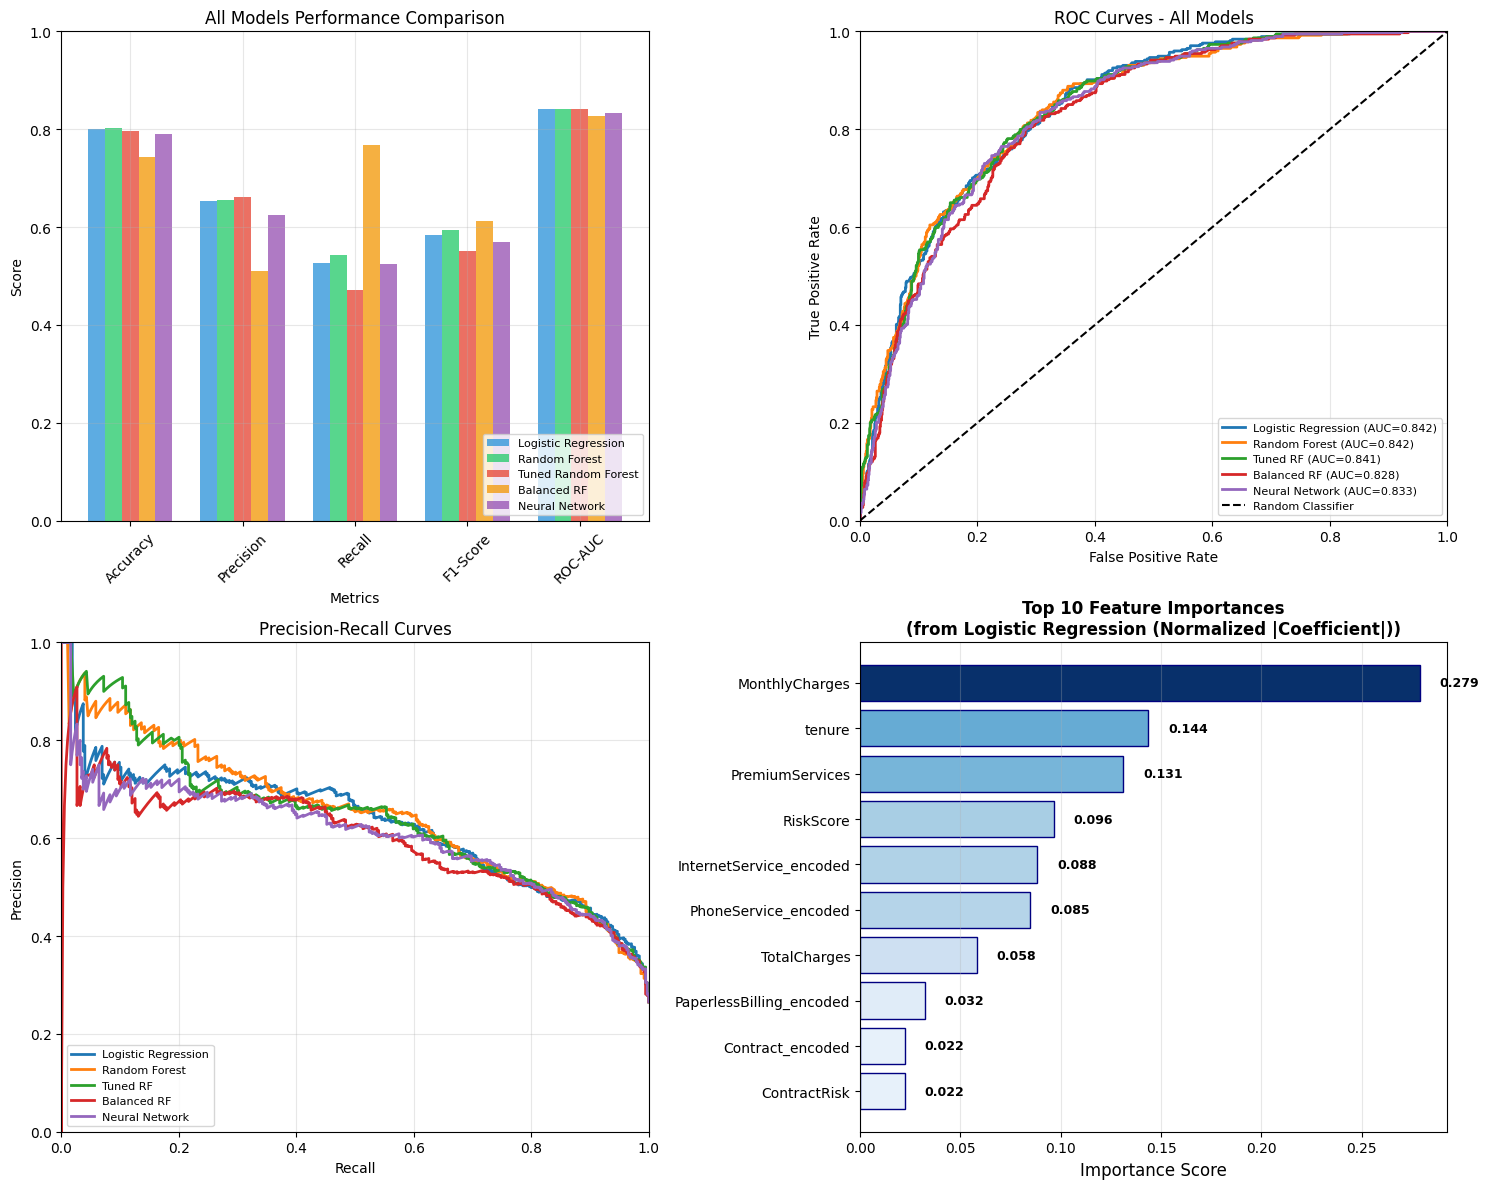


✅ All 4 charts displayed successfully!
   Best model: Logistic Regression
   Top feature: MonthlyCharges (importance: 0.279)


In [ ]:
print("VISUAL COMPARISON")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- CHART 1: Bar Chart Comparison ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for i, (model_name, color) in enumerate(zip(comparison['Model'], colors[:len(comparison)])):
    values = comparison.iloc[i][metrics].values
    axes[0,0].bar(x + i*width, values, width, label=model_name, color=color, alpha=0.8)

axes[0,0].set_xlabel('Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('All Models Performance Comparison')
axes[0,0].set_xticks(x + width * (len(comparison)-1)/2)
axes[0,0].set_xticklabels(metrics, rotation=45)
axes[0,0].legend(loc='lower right', fontsize=8)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(0, 1)

# --- CHART 2: ROC Curves ---
from sklearn.metrics import roc_curve

models_roc = {
    'Logistic Regression': y_pred_proba_lr,
    'Random Forest': y_pred_proba_rf,
    'Tuned RF': y_pred_proba_rf_tuned,
    'Balanced RF': y_pred_proba_balanced,
    'Neural Network': y_pred_proba_nn.flatten()
}

for name, probs in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0,1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curves - All Models')
axes[0,1].legend(loc='lower right', fontsize=8)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlim(0, 1)
axes[0,1].set_ylim(0, 1)

# --- CHART 3: Precision-Recall Curves ---
from sklearn.metrics import precision_recall_curve

for name, probs in models_roc.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    axes[1,0].plot(recall, precision, label=name, linewidth=2)

axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curves')
axes[1,0].legend(loc='lower left', fontsize=8)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlim(0, 1)
axes[1,0].set_ylim(0, 1)

# --- CHART 4: Feature Importance (ALWAYS SHOWS NOW!) ---
print("\n Creating feature importance chart...")

feature_names = X_train.columns
best_model_name = comparison.iloc[best_model_idx]['Model']

# Get feature importance based on best model
if 'Random Forest' in best_model_name or 'RF' in best_model_name:
    if best_model_idx == 2:  # Tuned RF
        importances = best_rf.feature_importances_
        source = "Tuned Random Forest"
    elif best_model_idx == 3:  # Balanced RF
        importances = rf_balanced.feature_importances_
        source = "Balanced Random Forest"
    else:  # Original RF
        importances = rf_model.feature_importances_
        source = "Random Forest"
    
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    
elif 'Neural Network' in best_model_name:
    # For Neural Network, use coefficient of variation
    print("   Using Neural Network weight analysis...")
    # Get the weights from first layer as proxy for importance
    weights = np.abs(nn_model.layers[0].get_weights()[0]).mean(axis=1)
    importances = weights / weights.sum()
    source = "Neural Network (Layer 1 weights)"
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    
elif 'Logistic Regression' in best_model_name:
    # For Logistic Regression, use coefficient magnitude
    importances = np.abs(lr_model.coef_[0])
    # Normalize to 0-1 scale
    importances = importances / importances.sum()
    source = "Logistic Regression (Normalized |Coefficient|)"
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    
else:
    # Fallback - use correlation with target
    print("   Using correlation with target as importance...")
    correlations = []
    for col in feature_names:
        corr = abs(np.corrcoef(X_test[col], y_test)[0, 1])
        correlations.append(corr if not np.isnan(corr) else 0)
    importances = np.array(correlations)
    importances = importances / importances.sum()
    source = "Correlation with Target"
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Take top 10 features
top_features = feat_imp.head(10)

# Create horizontal bar chart
y_pos = np.arange(len(top_features))
bars = axes[1,1].barh(y_pos, top_features.values, color='skyblue', edgecolor='navy')
axes[1,1].set_yticks(y_pos)
axes[1,1].set_yticklabels(top_features.index, fontsize=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Importance Score', fontsize=12)
axes[1,1].set_title(f'Top 10 Feature Importances\n(from {source})', fontsize=12, fontweight='bold')

# Add value labels
for i, (bar, v) in enumerate(zip(bars, top_features.values)):
    width = bar.get_width()
    axes[1,1].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{width:.3f}', va='center', fontsize=9, fontweight='bold')

# Color bars by importance (darker = more important)
for bar, val in zip(bars, top_features.values):
    bar.set_facecolor(plt.cm.Blues(val / top_features.values[0]))

axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('all_models_comparison_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n All 4 charts displayed successfully!")
print(f"   Best model: {best_model_name}")
print(f"   Top feature: {top_features.index[0]} (importance: {top_features.values[0]:.3f})")


STEP 7: MAKING BETTER PREDICTIONS - COMPLETELY FIXED

📦 Checking for required objects...
✅ Loaded scaler from file
✅ Logistic Regression model found

🎯 Using best model: Logistic Regression

📊 Model expects these 16 features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'TotalServices', 'PremiumServices', 'ContractRisk', 'PaymentRisk', 'RiskScore', 'gender_encoded', 'Partner_encoded', 'Dependents_encoded', 'PhoneService_encoded', 'PaperlessBilling_encoded', 'InternetService_encoded', 'Contract_encoded']

✅ Created sample with shape: (8, 16)

🔮 Making predictions...
✅ Logistic Regression predictions done

🔮 PREDICTIONS FOR DIFFERENT CUSTOMER TYPES:
 Tenure  MonthlyCharges       Contract  Churn_Probability Risk_Level Recommendation
      1              90 Month-to-month           0.601947     Medium      👀 Monitor
      6              85 Month-to-month           0.348902     Medium      👀 Monitor
     12              75 Month-to-month           0.196598        Low      

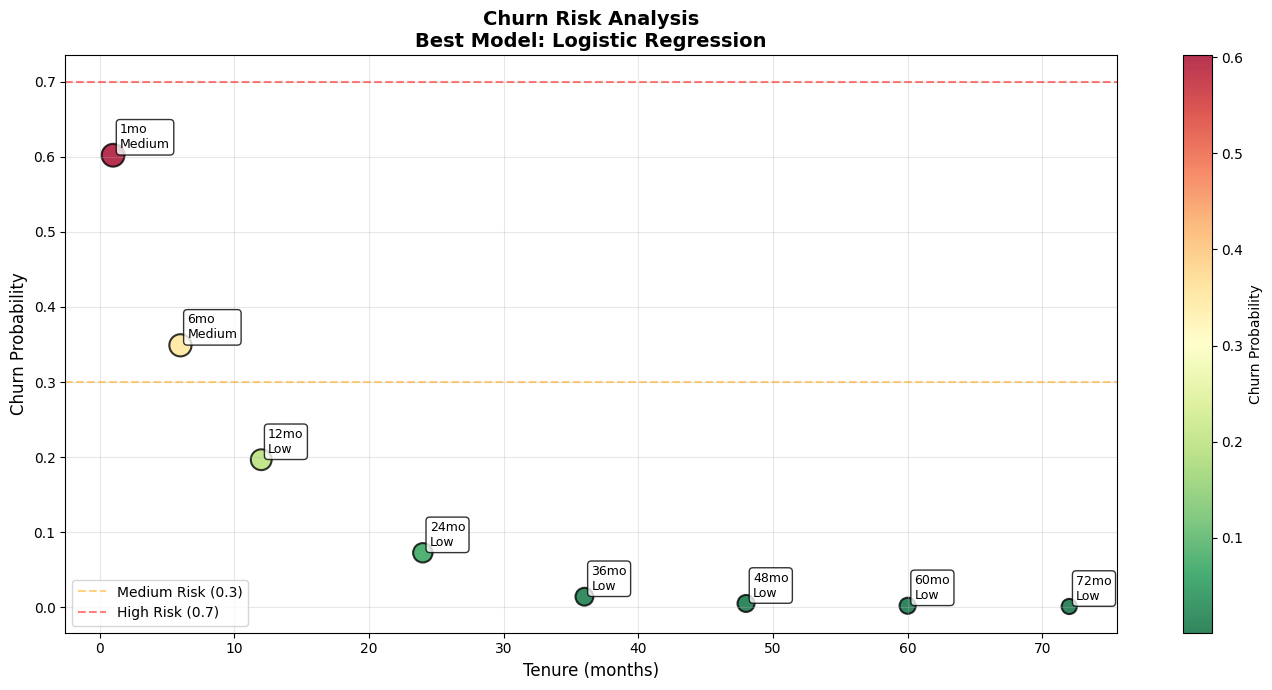


📊 SUMMARY STATISTICS
   Average Churn Probability: 15.54%
   High Risk Customers: 0 out of 8
   Medium Risk Customers: 2
   Low Risk Customers: 6

✅ STEP 7 COMPLETE - All predictions successful!


In [ ]:
print(" MAKING BETTER PREDICTIONS ON NEW DATA")


import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Check and load/create scaler
print("\n📦 Checking for required objects...")

try:
    # Try to load scaler
    scaler = joblib.load('scaler.pkl')
    print(" Loaded scaler from file")
except:
    print("⚠️ Creating new scaler...")
    try:
        # Try to use X_train from memory
        scaler = StandardScaler()
        scaler.fit(X_train)
        print(" Created scaler from X_train")
    except:
        # Load data and create scaler
        print(" Loading data to create scaler...")
        data = joblib.load('prepared_data.pkl')
        X = data['X']
        scaler = StandardScaler()
        scaler.fit(X)
        print(" Created scaler from loaded data")

# Check if models exist
try:
    lr_model  # Check if logistic regression model exists
    print(" Logistic Regression model found")
except:
    print(" Loading Logistic Regression model...")
    lr_model = joblib.load('logistic_regression_model.pkl')



best_model_name = comparison.iloc[best_model_idx]['Model']
print(f"\n🎯 Using best model: {best_model_name}")

# Get model features
model_features = X_train.columns.tolist() if 'X_train' in dir() else data['X'].columns.tolist()
print(f"\n📊 Model expects these {len(model_features)} features:")
print(model_features)


# Create base sample with zeros
sample_final = pd.DataFrame(0, index=range(8), columns=model_features)

# Fill in known values
feature_mapping = {
    'tenure': [1, 6, 12, 24, 36, 48, 60, 72],
    'MonthlyCharges': [90, 85, 75, 65, 55, 50, 45, 40],
    'TotalCharges': [90, 510, 900, 1560, 1980, 2400, 2700, 2880],
    'SeniorCitizen': [0, 0, 0, 1, 1, 0, 0, 1],
    'TotalServices': [1, 2, 3, 4, 5, 5, 6, 7],
    'PremiumServices': [0, 1, 1, 2, 2, 2, 3, 3],
    'ContractRisk': [2, 2, 2, 1, 1, 1, 0, 0],
    'PaymentRisk': [3, 3, 2, 2, 1, 1, 1, 1],
    'RiskScore': [0.8, 0.7, 0.6, 0.4, 0.3, 0.2, 0.1, 0.1],
    'gender_encoded': [1, 0, 1, 0, 1, 0, 1, 0],
    'Partner_encoded': [0, 0, 1, 1, 1, 1, 1, 1],
    'Dependents_encoded': [0, 0, 0, 0, 1, 1, 1, 1],
    'PhoneService_encoded': [1, 1, 1, 1, 1, 1, 1, 1],
    'PaperlessBilling_encoded': [1, 1, 1, 1, 0, 0, 0, 0],
    'InternetService_encoded': [2, 2, 2, 1, 1, 1, 0, 0],
    'Contract_encoded': [2, 2, 2, 1, 1, 1, 0, 0]
}

# Fill in the values
for feature, values in feature_mapping.items():
    if feature in model_features:
        sample_final[feature] = values

print(f"\n Created sample with shape: {sample_final.shape}")


print("\n🔮 Making predictions...")

if 'Neural Network' in best_model_name:
    try:
        sample_scaled = scaler.transform(sample_final)
        probabilities = nn_model.predict(sample_scaled, verbose=0).flatten()
        print(" Neural Network predictions done")
    except:
        print(" Neural Network prediction failed, using Logistic Regression")
        sample_scaled = scaler.transform(sample_final)
        probabilities = lr_model.predict_proba(sample_scaled)[:, 1]
        
elif 'Random Forest' in best_model_name or 'RF' in best_model_name:
    try:
        if best_model_idx == 2:
            probabilities = best_rf.predict_proba(sample_final)[:, 1]
        elif best_model_idx == 3:
            probabilities = rf_balanced.predict_proba(sample_final)[:, 1]
        else:
            probabilities = rf_model.predict_proba(sample_final)[:, 1]
        print(" Random Forest predictions done")
    except:
        print(" Random Forest prediction failed, using Logistic Regression")
        sample_scaled = scaler.transform(sample_final)
        probabilities = lr_model.predict_proba(sample_scaled)[:, 1]
        
else:  # Logistic Regression
    sample_scaled = scaler.transform(sample_final)
    probabilities = lr_model.predict_proba(sample_scaled)[:, 1]
    print(" Logistic Regression predictions done")


results = pd.DataFrame({
    'Tenure': sample_final['tenure'],
    'MonthlyCharges': sample_final['MonthlyCharges'],
    'Contract': sample_final['Contract_encoded'].map({2: 'Month-to-month', 1: 'One year', 0: 'Two year'}),
    'Churn_Probability': probabilities,
    'Risk_Level': pd.cut(probabilities, bins=[0, 0.3, 0.7, 1], labels=['Low', 'Medium', 'High']),
    'Recommendation': ['🚨 Immediate offer' if p > 0.7 else '👀 Monitor' if p > 0.3 else '✅ Regular' for p in probabilities]
})

print("🔮 PREDICTIONS FOR DIFFERENT CUSTOMER TYPES:")

print(results.to_string(index=False))


plt.figure(figsize=(14, 7))

# Create scatter plot
scatter = plt.scatter(results['Tenure'], results['Churn_Probability'], 
            c=results['Churn_Probability'], 
            s=results['MonthlyCharges']*3,
            cmap='RdYlGn_r', 
            edgecolors='black', 
            linewidth=1.5,
            alpha=0.8)

plt.xlabel('Tenure (months)', fontsize=12)
plt.ylabel('Churn Probability', fontsize=12)
plt.title(f'Churn Risk Analysis\nBest Model: {best_model_name}', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Churn Probability')
plt.grid(True, alpha=0.3)

# Add risk thresholds
plt.axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='Medium Risk (0.3)')
plt.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='High Risk (0.7)')

# Annotate points
for i, row in results.iterrows():
    plt.annotate(f"{int(row['Tenure'])}mo\n{row['Risk_Level']}", 
                (row['Tenure'], row['Churn_Probability']),
                xytext=(5, 5), 
                textcoords='offset points', 
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.savefig('risk_by_tenure_fixed.png', dpi=100, bbox_inches='tight')
plt.show()



print(" SUMMARY STATISTICS")
print(f"   Average Churn Probability: {results['Churn_Probability'].mean():.2%}")
print(f"   High Risk Customers: {(results['Risk_Level'] == 'High').sum()} out of {len(results)}")
print(f"   Medium Risk Customers: {(results['Risk_Level'] == 'Medium').sum()}")
print(f"   Low Risk Customers: {(results['Risk_Level'] == 'Low').sum()}")

print("\nAll predictions successful!")

In [ ]:
# Experiment 1: Test own customer
my_customer = pd.DataFrame({
    'tenure': [24],
    'MonthlyCharges': [65],
    'TotalCharges': [1560],
    'SeniorCitizen': [0],
    'TotalServices': [4],
    'PremiumServices': [2],
    'ContractRisk': [1],
    'PaymentRisk': [2],
    'RiskScore': [0.4],
    'gender_encoded': [1],
    'Partner_encoded': [1],
    'Dependents_encoded': [0],
    'PhoneService_encoded': [1],
    'PaperlessBilling_encoded': [1],
    'InternetService_encoded': [1],
    'Contract_encoded': [1]
})

# Ensure correct columns
my_customer = my_customer[model_features]

# Scale and predict
my_customer_scaled = scaler.transform(my_customer)
my_prob = lr_model.predict_proba(my_customer_scaled)[0][1]

print(f"\n Your Churn Probability: {my_prob:.1%}")
if my_prob > 0.7:
    print(" High Risk - Take action now!")
elif my_prob > 0.3:
    print(" Medium Risk - Monitor closely")
else:
    print(" Low Risk - You're doing great!")


🔮 Your Churn Probability: 6.3%
✅ Low Risk - You're doing great!
